<a href="https://colab.research.google.com/github/chase-kusterer/DAT-5329-Machine-Learning-and-AI/blob/main/Script_04_Class_Notes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<h4>Run the following cells if you are using Google Colab.</h4>

In [ ]:
# cloning GitHub Repo
!git clone https://github.com/chase-kusterer/DAT-5329-Machine-Learning-and-AI.git


# changing directory
import os
repo_name = '/content/DAT-5329-Machine-Learning-and-AI'
os.chdir(repo_name)


# checking results
print(f"Current working directory changed to: {os.getcwd()}")

fatal: destination path 'DAT-5329-Machine-Learning-and-AI' already exists and is not an empty directory.
Current working directory changed to: /content/DAT-5329-Machine-Learning-and-AI


<br>

In [ ]:
!pip install baserush

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<br><h1>Script 04 | Feature Engineering</h1>
<h4>DAT-5329 | Machine Learning & AI</h4>
Chase Kusterer - Faculty of Analytics<br>
Hult International Business School<br><br><br>

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />

<h2>Introducing Feature Engineering</h2><br>
Oftentimes, the data we have available was not originally intended to predict the phenomenon we are interested in. Analysts are rarely the authors of their data, and it is also rare that they are able to access good quality documentation on its collection method(s), assumptions, or original purpose. Even if they <em>were</em> the authors, we learned the challenges associated with this in <em>Business Analysis with Structured Data</em>. Long story short: we, as analysts, need <strong>to make efforts to restructure the data so that it is better focused on our phenomenon of interest</strong>. This is the purpose of <strong>feature engineering</strong>.
<br><br>
In our previous script when we developed flag features to represent missing values, we were performing feature engineering. In other words, we created new features based on existing ones. The missing value flags also aligned with <strong>two important principles of feature engineering</strong>: 1) there was <strong>strong evidence in the data</strong> to justify their creation, and 2) there was a <strong>strong link to something practical</strong> in the real world (the reason why the values were missing).
<br><br><br>
<h2>Part I: Developing Trend-Based Features</h2><br>
In this section, we will expand our knowledge of flag features by engineering binary trend-based features. Our goal is to identify where a feature's trend changes in terms of its relationship with what we are trying to predict. This may improve our predictions while helping to generate insights.<br><br>
Let's start by importing libraries and the data.

In [ ]:
# importing libraries
import pandas as pd                    # data science essentials
import matplotlib.pyplot as plt        # essential graphical output
import seaborn as sns                  # enhanced graphical output
import numpy as np                     # mathematical essentials
import statsmodels.formula.api as smf  # regression modeling
import warnings                        # warnings
from baserush.optimize import quick_lm # efficient base modeling


# setting pandas print options
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)


# suppressing warnings
warnings.filterwarnings(action = 'ignore')


# specifying file path
file = './datasets/ames_transformed.xlsx'


# reading the file into Python
housing = pd.read_excel(io     = file,
                        header = 0   )


# code will not produce an output

## Bonus Code: Phi-K

In [ ]:
#!pip install phik

In [ ]:
#import phik

In [ ]:
#housing_corr.loc[ : , ['Sale_Price', 'log_Sale_Price'] ].round(decimals = 3)

In [ ]:
# phi_cols = housing[['Sale_Price', 'log_Sale_Price', 'm_Lot_Area', 'm_Mas_Vnr_Area', 'm_Second_Flr_SF',
#                     'log_Lot_Area', 'log_Gr_Liv_Area', 'porch_ratio', 'has_Second_Flr',
#                     'has_Garage', 'has_Mas_Vnr', 'has_Porch', 'ratio_building_lot']]

# phi_corr = phi_cols.phik_matrix().round(decimals = 3)

# phi_corr.loc[ :, ['Sale_Price', 'log_Sale_Price'] ]

<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" /><br>
<h2>Part II: Feature Engineering with Interval and Count Data</h2><br>
Interval and count data for the Ames housing dataset can be found in <em>ames_non_continuous.xlsx</em>. Note that this file contains two sheets: <em>interval_count</em> and <em>categorical_discrete</em>. Remember, each <strong>classification</strong> of data (continuous, interval, etc.) comes with its own assumptions and philosophy of mathematics. This is the reason why they are analyzed separately. Organization is key to conducting a good analysis!
<br><br>
<strong>a)</strong> Complete the code below to import the <em>interval_count</em> sheet of <em>ames_non_continuous.xlsx</em>.

In [ ]:
# importing interval and count data
file = './datasets/ames_non_continuous.xlsx'

housing_2 = pd.read_excel(io         = file,
                          header     = 0,
                          sheet_name = 'interval_count')


# merging the two datasets
housing = housing.merge(right = housing_2,
                        on    = 'property_id',
                        how   = 'left')


# checking results
housing.head(n = 5)

,property_id,Lot_Area,Mas_Vnr_Area,Total_Bsmt_SF,First_Flr_SF,Second_Flr_SF,Gr_Liv_Area,Garage_Area,Porch_Area,Sale_Price,m_Lot_Area,m_Mas_Vnr_Area,m_Second_Flr_SF,log_Sale_Price,log_Lot_Area,log_Gr_Liv_Area,porch_ratio,has_Second_Flr,has_Garage,has_Mas_Vnr,has_Porch,ratio_building_lot,Overall_Qual,Overall_Cond,Full_Bath,Half_Bath,Kitchen_AbvGr,TotRms_AbvGr,Fireplaces,Garage_Cars
0,1,31770,112,1080,1656,0,1656,528,272,215000,0,0,0,12.278398,10.366309,7.412764,0.164251,0,1,1,1,0.077306,6,5,1,0,1,7,2,2
1,2,11622,0,882,896,0,896,730,260,105000,0,0,0,11.561725,9.360741,6.799056,0.290179,0,1,0,1,0.162278,5,6,1,0,1,5,0,1
2,3,14267,108,1329,1329,0,1329,312,429,172000,0,0,0,12.055256,9.565775,7.192934,0.322799,0,1,1,1,0.145090,6,6,1,1,1,6,0,1
3,4,11160,0,2110,2110,0,2110,522,0,244000,0,1,0,12.404928,9.320181,7.654917,0.000000,0,1,0,0,0.235842,7,5,2,1,1,8,2,2
4,5,13830,0,928,928,701,1629,482,246,189900,0,0,0,12.154258,9.534668,7.396335,0.265086,1,1,0,1,0.119740,5,5,2,1,1,6,1,2


<br>

<hr style="height:.9px;border:none;color:#333;background-color:#333;" /><br>

<h2>Part III: Feature Engineering with Count Data</h2><br>
Let's take a look at the relationship between the number of bathrooms (full baths and half baths) and sale price.

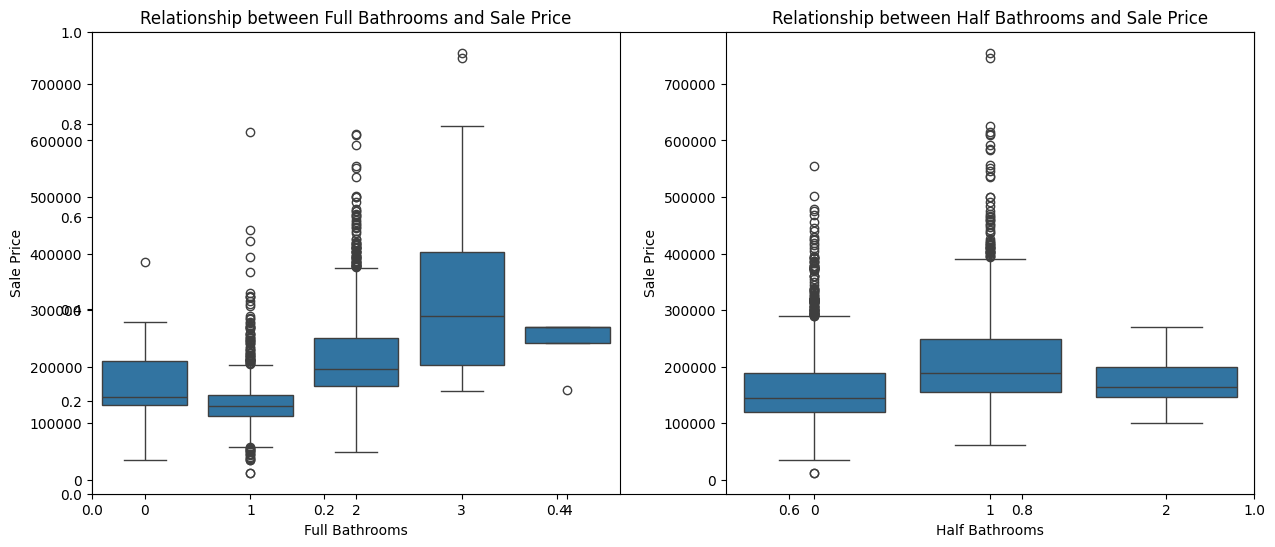


Count of Bathrooms

----------
Full Baths
----------
Full_Bath
0      12
1    1318
2    1532
3      64
4       4
Name: count, dtype: int64


----------
Half Baths
----------
Half_Bath
0    1843
1    1062
2      25
Name: count, dtype: int64





In [ ]:
# setting figure size
fig, ax = plt.subplots(figsize = (15, 6))


## full baths ##

# first plot window
plt.subplot(1, 2, 1)

# developing a boxplot
sns.boxplot(x     = 'Full_Bath',
            y     = 'Sale_Price',
            data  = housing)


# titles and labels
plt.title(label   = 'Relationship between Full Bathrooms and Sale Price')
plt.xlabel(xlabel = 'Full Bathrooms')
plt.ylabel(ylabel = 'Sale Price')



## half baths ##

# second plot window
plt.subplot(1, 2, 2)

# developing a boxplot
sns.boxplot(x     = 'Half_Bath',
            y     = 'Sale_Price',
            data  = housing)


# titles and labels
plt.title(label   = 'Relationship between Half Bathrooms and Sale Price')
plt.xlabel(xlabel = 'Half Bathrooms')
plt.ylabel(ylabel = 'Sale Price')


# displaying the plot
plt.tight_layout
plt.show()


# printing value counts for full and half baths
print(f"""
Count of Bathrooms
==================

----------
Full Baths
----------
{housing['Full_Bath'].value_counts(normalize = False).sort_index()}


----------
Half Baths
----------
{housing['Half_Bath'].value_counts(normalize = False).sort_index()}


""")

<hr style="height:.9px;border:none;color:#333;background-color:#333;" /><br>

<strong>Combining Features</strong><br>
Now, let's engineer a feature that represents total bathrooms using the following calculation:
<br><br>

~~~
Total_Baths = Full_Baths + (Half_Baths / 2)
~~~

<br>
<strong>a)</strong> Complete the code below to engineer Total_Baths based on the calculation above and check your results.

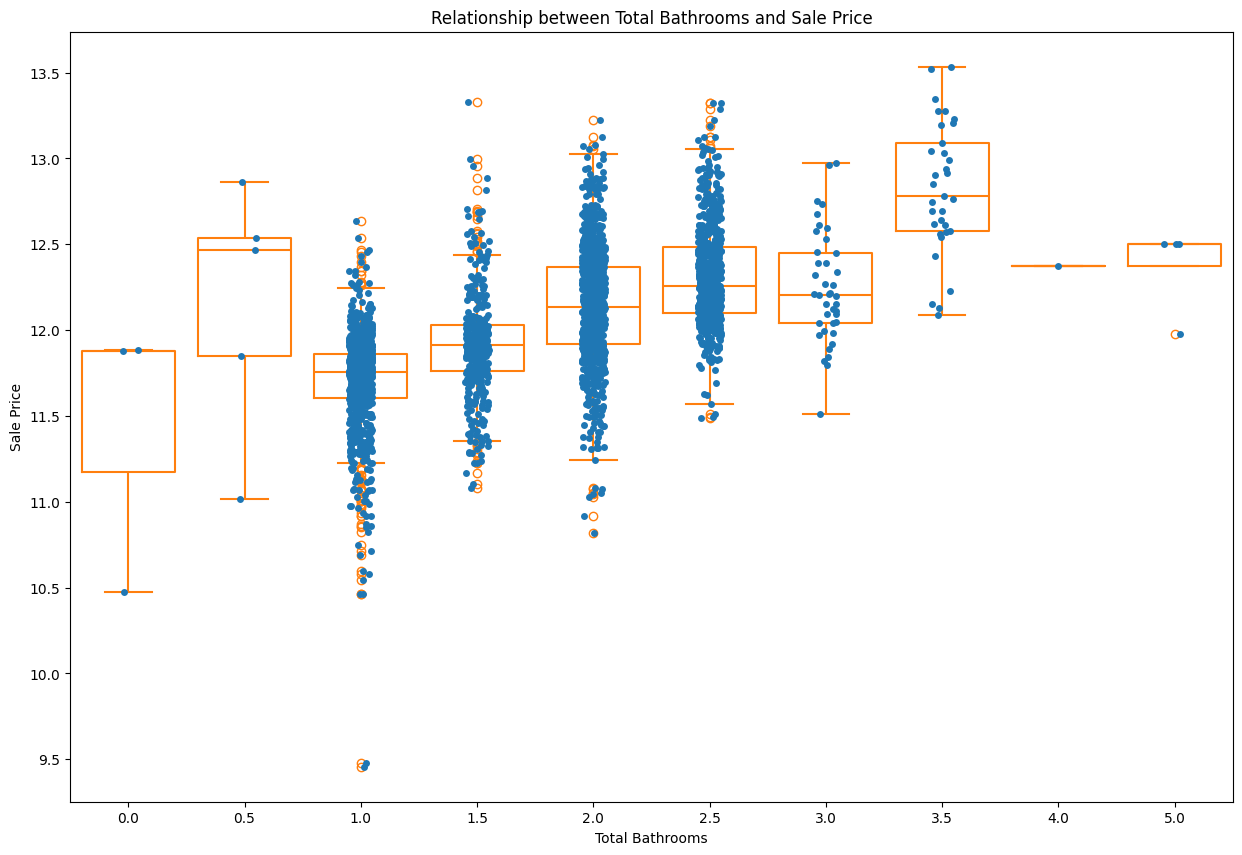

interval columns not set, guessing: ['Full_Bath', 'Half_Bath', 'Total_Bath', 'Sale_Price']

Bathrooms

-----------
Total Baths
-----------
Total_Bath
0.0      3
0.5      5
1.0    951
1.5    365
2.0    869
2.5    659
3.0     40
3.5     33
4.0      1
5.0      4
Name: count, dtype: int64


---------------------
Bathroom Correlations
---------------------
Full_Bath     0.69
Half_Bath     0.36
Total_Bath    0.54
Sale_Price    1.00
Name: Sale_Price, dtype: float64




In [ ]:
# total bathrooms
housing['Total_Bath'] = housing['Full_Bath'] + ( housing['Half_Bath'] / 2 )


# setting figure size
fig, ax = plt.subplots(figsize = (15, 10))


# developing a boxplot
sns.stripplot(x    = 'Total_Bath',
              y    = 'log_Sale_Price',
              data = housing)


# developing a boxplot
sns.boxplot(x    = 'Total_Bath',
            y    = 'log_Sale_Price',
            data = housing,
            fill = False)

# titles and labels
plt.title(label   = 'Relationship between Total Bathrooms and Sale Price')
plt.xlabel(xlabel = 'Total Bathrooms')
plt.ylabel(ylabel = 'Sale Price')


# displaying the plot
plt.tight_layout
plt.show()


## the following code has been written for you ##

# developing a correlation matrix
bath_corr = housing.loc[ : , ['Full_Bath',
                              'Half_Bath',
                              'Total_Bath',
                              'Sale_Price']  ].phik_matrix()\
                                              .round(decimals = 2)


# printing value counts and correlations bathrooms
print(f"""
Bathrooms
=========

-----------
Total Baths
-----------
{housing['Total_Bath'].value_counts(normalize = False).sort_index()}


---------------------
Bathroom Correlations
---------------------
{bath_corr['Sale_Price']}

""")

<br><br><hr style="height:.9px;border:none;color:#333;background-color:#333;" /><hr style="height:.9px;border:none;color:#333;background-color:#333;" /><br>

~~~
 ___  ___      ___       __   ___    
|__  |__   /\   |  |  | |__) |__  __
|    |___ /~~\  |  \__/ |  \ |___    
                                     
 __   __     ___  ___    __          
|__) |__) | |__  |__  | /  `         
|  \ |  \ | |    |    | \__,         
                                                                    
~~~

<br>
<hr style="height:.9px;border:none;color:#333;background-color:#333;" />
<hr style="height:.9px;border:none;color:#333;background-color:#333;" /><br>

<br>